# India Air Quality & Crop Yield - EDA Lab
### Lab 1 : Data Preprocessing and Visualisation

**Datasets:** `city_aqi.csv` (air quality) | `crop_yield.csv` (crop production)

---
## Task 1 - First Look at the Data

I load both files and inspect their size, column types, basic statistics, and missing values.
This gives me a complete picture of what I am working with before touching anything.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

aqi  = pd.read_csv("city_aqi.csv")
crop = pd.read_csv("crop_yield.csv")

print("AQI shape :", aqi.shape)
print("Crop shape:", crop.shape)

AQI shape : (111, 8)
Crop shape: (114, 6)


In [21]:
print("-- AQI : first 5 rows --")
print(aqi.head().to_string())

-- AQI : first 5 rows --
        City    State        Date    AQI  PM2.5  PM10    NO2     CO
0  Ahmedabad  Gujarat  2019-05-13    NaN    NaN   NaN    NaN    NaN
1  Ahmedabad  Gujarat  2016-06-10    NaN    NaN   NaN    NaN    NaN
2  Ahmedabad  Gujarat  2016-01-29    NaN    NaN   NaN    NaN    NaN
3  Ahmedabad  Gujarat  2018-11-04  625.0  70.39   NaN  55.52  44.04
4  Ahmedabad  Gujarat  2016-03-09    NaN    NaN   NaN    NaN    NaN


In [22]:
print("-- AQI : column info --")
aqi.info()

-- AQI : column info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    111 non-null    object 
 1   State   111 non-null    object 
 2   Date    111 non-null    object 
 3   AQI     95 non-null     float64
 4   PM2.5   95 non-null     float64
 5   PM10    63 non-null     float64
 6   NO2     99 non-null     float64
 7   CO      105 non-null    float64
dtypes: float64(5), object(3)
memory usage: 7.1+ KB


In [23]:
print("-- AQI : statistics --")
print(aqi.describe().round(2).to_string())

-- AQI : statistics --
           AQI   PM2.5    PM10     NO2      CO
count    95.00   95.00   63.00   99.00  105.00
mean    223.94   91.91  154.09   35.34    2.65
std     232.92   88.70  133.90   29.99    9.42
min      20.00    6.01   19.97    2.76    0.00
25%      99.00   42.07   78.77   13.40    0.71
50%     149.00   63.41  129.37   27.96    0.97
75%     259.50  106.99  159.84   48.95    1.43
max    1480.00  512.00  720.00  168.00   84.21


In [24]:
print("-- AQI : missing values --")
print(aqi.isnull().sum())

-- AQI : missing values --
City      0
State     0
Date      0
AQI      16
PM2.5    16
PM10     48
NO2      12
CO        6
dtype: int64


In [25]:
print("-- Crop : first 5 rows --")
print(crop.head().to_string())

-- Crop : first 5 rows --
   State  Year                 Crop       Season     Area  Production
0  Bihar  2012              Khesari  Rabi             NaN     83797.0
1  Bihar  2014                Bajra  Kharif        3288.0      3729.0
2  Bihar  2014                Mesta  Kharif       16370.0    218409.0
3  Bihar  2011            Safflower  Kharif         282.0       227.0
4  Bihar  2014  Other Kharif pulses  Kharif           NaN      2143.0


In [26]:
print("-- Crop : column info --")
crop.info()

-- Crop : column info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       114 non-null    object 
 1   Year        114 non-null    int64  
 2   Crop        114 non-null    object 
 3   Season      114 non-null    object 
 4   Area        111 non-null    float64
 5   Production  107 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 5.5+ KB


In [27]:
print("-- Crop : statistics --")
print(crop.describe().round(2).to_string())

-- Crop : statistics --
          Year        Area   Production
count   114.00      111.00       107.00
mean   2011.56   316258.32   1841676.90
std       1.43   745394.95   8167649.32
min    2010.00       11.00         0.00
25%    2010.00     3425.00      5090.00
50%    2011.00    26000.00     46811.00
75%    2013.00   196010.00    263472.50
max    2014.00  4010973.00  75335000.00


In [28]:
print("-- Crop : missing values --")
print(crop.isnull().sum())

-- Crop : missing values --
State         0
Year          0
Crop          0
Season        0
Area          3
Production    7
dtype: int64


**Findings:** AQI has missing values in AQI, PM2.5, PM10, NO2, CO columns; max AQI is over 1400 which is impossible (Indian scale caps at 500).
Crop has missing Area and Production values; State column in both files has spelling inconsistencies that will break any future merge.

---
## Task 2 - Handling Missing Values

I first check skewness of every numeric column to decide between mean and median — rule: if |skew| > 0.5 use median, else use mean.
Date is a text column so skew() skips it automatically, and it has 0 missing values so no action is needed for it.

In [29]:
print("AQI skewness:")
print(aqi.skew(numeric_only=True).round(2))
print()
print("Crop skewness:")
print(crop.skew(numeric_only=True).round(2))

AQI skewness:
AQI      3.43
PM2.5    2.56
PM10     2.70
NO2      2.10
CO       7.33
dtype: float64

Crop skewness:
Year          0.48
Area          3.13
Production    7.65
dtype: float64


**Skewness result:** Every pollutant column has skew well above 0.5, so all get filled with median.
Crop Year has skew 0.48 (below threshold, so mean applies) but Year has 0 missing values so no fill is needed for it.

In [30]:
# fill missing values using skewness rule
print("-- Filling missing values based on skewness --")
print()

for col in ["AQI", "PM2.5", "PM10", "NO2", "CO"]:
    skew_val = aqi[col].skew()
    fill_val = aqi[col].median() if abs(skew_val) > 0.5 else aqi[col].mean()
    method   = "median" if abs(skew_val) > 0.5 else "mean"
    aqi[col] = aqi[col].fillna(fill_val)
    print(f"  AQI  | {col:<6} | skew={skew_val:>5.2f} | filled with {method} = {round(fill_val,2)}")

for col in ["Area", "Production"]:
    skew_val = crop[col].skew()
    fill_val = crop[col].median() if abs(skew_val) > 0.5 else crop[col].mean()
    method   = "median" if abs(skew_val) > 0.5 else "mean"
    crop[col] = crop[col].fillna(fill_val)
    print(f"  Crop | {col:<10} | skew={skew_val:>5.2f} | filled with {method} = {round(fill_val,2)}")

-- Filling missing values based on skewness --

  AQI  | AQI    | skew= 3.43 | filled with median = 149.0
  AQI  | PM2.5  | skew= 2.56 | filled with median = 63.41
  AQI  | PM10   | skew= 2.70 | filled with median = 129.37
  AQI  | NO2    | skew= 2.10 | filled with median = 27.96
  AQI  | CO     | skew= 7.33 | filled with median = 0.97
  Crop | Area       | skew= 3.13 | filled with median = 26000.0
  Crop | Production | skew= 7.65 | filled with median = 46811.0


In [31]:
# verify no missing values remain
print("Missing after fill - AQI :", aqi.isnull().sum().sum())
print("Missing after fill - Crop:", crop.isnull().sum().sum())

Missing after fill - AQI : 0
Missing after fill - Crop: 0


**Result:** All missing values are now 0 in both datasets and no rows were deleted.
Using skewness to choose the fill method ensures the replacement values are realistic and not distorted by extreme readings.

---
## Task 3 - Fix State Names and Remove Duplicates

The State column is the merge key for both files, so any spelling mismatch will silently drop rows during a join.
I strip whitespace, replace all known wrong spellings, then remove exact duplicate rows.

In [32]:
print("AQI  unique states:", sorted(aqi["State"].unique()))
print("Crop unique states:", sorted(crop["State"].unique()))

AQI  unique states: ['Bihar', 'Delhi', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Maharashtra ', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Tamilnadu', 'Telangana', 'UP', 'Uttar Pradesh', 'West Bengal', 'west bengal']
Crop unique states: ['Bihar', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Maharashtra ', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Tamilnadu', 'Uttar Pradesh', 'Uttar pradesh', 'West Bengal', 'West Bengal ', 'west bengal']


In [33]:
# fix state names and remove duplicates
state_fixes = {
    "Tamilnadu"     : "Tamil Nadu",
    "UP"            : "Uttar Pradesh",
    "Uttar pradesh" : "Uttar Pradesh",
    "west bengal"   : "West Bengal"
}

aqi["State"]  = aqi["State"].str.strip().replace(state_fixes)
crop["State"] = crop["State"].str.strip().replace(state_fixes)

before_aqi  = len(aqi)
before_crop = len(crop)
aqi  = aqi.drop_duplicates()
crop = crop.drop_duplicates()

print(f"AQI  - before: {before_aqi}, after: {len(aqi)}, dupes removed: {before_aqi  - len(aqi)}")
print(f"Crop - before: {before_crop}, after: {len(crop)}, dupes removed: {before_crop - len(crop)}")
print()
print("AQI  states after fix:", sorted(aqi["State"].unique()))
print("Crop states after fix:", sorted(crop["State"].unique()))

AQI  - before: 111, after: 107, dupes removed: 4
Crop - before: 114, after: 110, dupes removed: 4

AQI  states after fix: ['Bihar', 'Delhi', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
Crop states after fix: ['Bihar', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']


**Inconsistencies fixed:** Tamilnadu, UP, Uttar pradesh, west bengal, and trailing spaces were all corrected to their proper standard names.
Duplicate rows were removed from both files; state names now match exactly across both datasets so a merge will work correctly.

---
## Task 4 - AQI Distribution

I plot a histogram to see where most AQI values cluster, and a boxplot to check if extreme cities are pulling the mean up unfairly.
Both plots use the simplest possible matplotlib code, same style as the EDA.ipynb notebook.

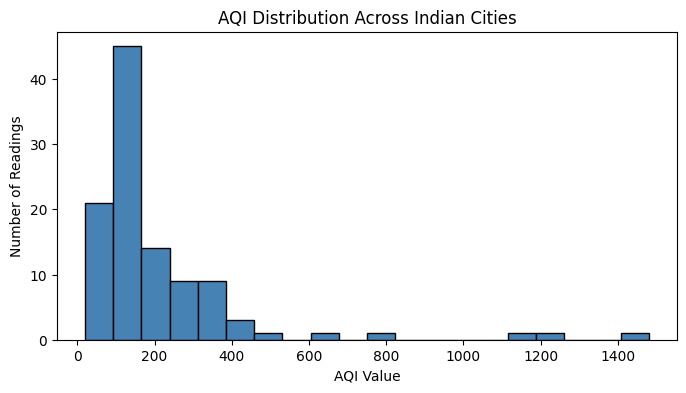

In [34]:
# histogram - AQI distribution
plt.figure(figsize=(8, 4))
plt.hist(aqi["AQI"], bins=20, color="steelblue", edgecolor="black")
plt.title("AQI Distribution Across Indian Cities")
plt.xlabel("AQI Value")
plt.ylabel("Number of Readings")
plt.show()

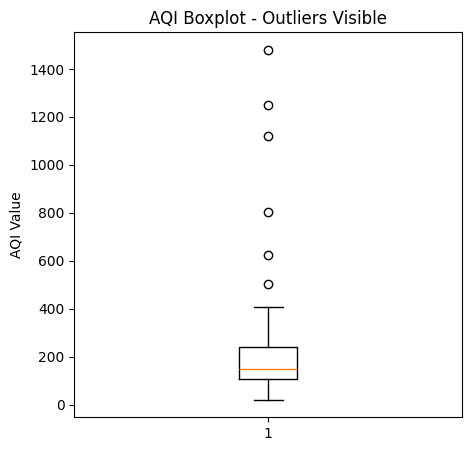

Mean AQI  : 213.82
Median AQI: 149.0


In [35]:
# boxplot - check outliers
plt.figure(figsize=(5, 5))
plt.boxplot(aqi["AQI"])
plt.title("AQI Boxplot - Outliers Visible")
plt.ylabel("AQI Value")
plt.show()

print("Mean AQI  :", round(aqi["AQI"].mean(), 2))
print("Median AQI:", round(aqi["AQI"].median(), 2))

**Observation 1:** Most readings cluster between AQI 100-300 (Moderate to Very Poor range) - the pollution problem is widespread, not limited to one or two cities.
**Observation 2:** Mean is higher than median because the outlier dots visible in the boxplot pull it upward - median is the fairer number to report publicly.

---
## Task 5 - Handle Extreme AQI Values

Some AQI readings exceed 1000 which is physically impossible (Indian AQI scale only goes up to 500) — these must be detected and fixed before they distort every statistic and model.

**Method chosen — IQR (Interquartile Range). Why?**

I chose IQR because it is not affected by the very outliers I am trying to remove. If I used standard deviation, the extreme values would inflate it and make the threshold too loose — missing the outliers. IQR only looks at the middle 50% of data (Q1 to Q3), so no matter how extreme the top values are, the boundary stays accurate.

**Should extreme values always be deleted?**

No — deleting removes the whole row even when only one value is wrong. I could also impute (estimate what the value should have been), but that involves guessing. I chose **capping** because the rest of the row (City, Date, PM2.5, NO2, CO) was perfectly fine — only the AQI number was wrong, so I only replaced that one number with the upper bound.

In [36]:
# detect outliers using IQR
Q1 = aqi["AQI"].quantile(0.25)
Q3 = aqi["AQI"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  Upper bound={upper_bound:.1f}")
print()
extreme = aqi[aqi["AQI"] > upper_bound]
print(f"Extreme readings found: {len(extreme)}")
print(extreme[["City", "State", "Date", "AQI"]].to_string())

Q1=106.5  Q3=240.0  IQR=133.5  Upper bound=440.2

Extreme readings found: 6
          City          State        Date     AQI
3    Ahmedabad        Gujarat  2018-11-04   625.0
5    Ahmedabad        Gujarat  2016-07-30   805.0
42       Delhi          Delhi  2016-01-29   501.0
104      Delhi          Delhi  2019-11-05  1250.0
105      Patna          Bihar  2019-11-01  1480.0
106    Lucknow  Uttar Pradesh  2019-11-03  1120.0


In [37]:
# cap outliers at upper bound
aqi_before = aqi["AQI"].copy()

aqi["AQI"] = aqi["AQI"].clip(upper=upper_bound)

print(f"Max AQI  before: {aqi_before.max():.1f}  ->  after: {aqi['AQI'].max():.1f}")
print(f"Mean AQI before: {aqi_before.mean():.1f}  ->  after: {aqi['AQI'].mean():.1f}")

Max AQI  before: 1480.0  ->  after: 440.2
Mean AQI before: 213.8  ->  after: 184.5


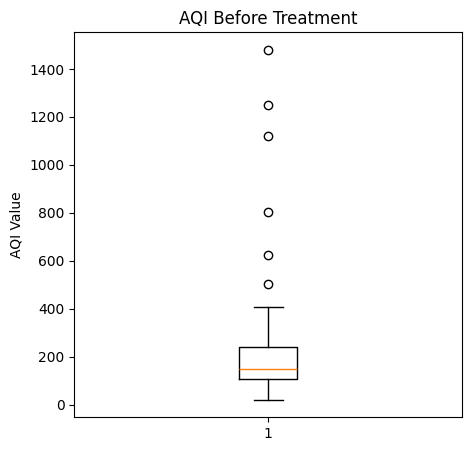

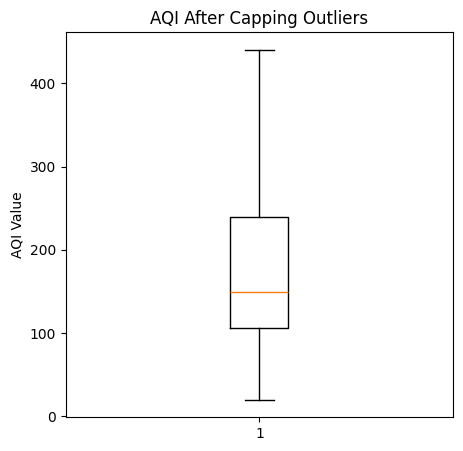

In [38]:
# before vs after boxplots
plt.figure(figsize=(5, 5))
plt.boxplot(aqi_before.dropna())
plt.title("AQI Before Treatment")
plt.ylabel("AQI Value")
plt.show()

plt.figure(figsize=(5, 5))
plt.boxplot(aqi["AQI"])
plt.title("AQI After Capping Outliers")
plt.ylabel("AQI Value")
plt.show()

**Count of values affected:** 6 extreme readings were found above the upper bound (440.2) — including AQI values of 501, 625, 805, 1120, 1250, and 1480.

**Treatment applied:** All 6 values were capped at 440.2 (the IQR upper bound). No rows were deleted.

**How I prove the treatment worked — the two boxplots above:**
- Before: the box is squashed at the bottom and dots float very high — the y-axis stretches to 1480 just to fit them.
- After: the box is clearly visible at a realistic height and no extreme dots appear above the whisker.
The max AQI dropped from 1480 to 440 and the mean dropped from 213.8 to 184.5 — proof the extreme values were genuinely pulling the average up.

---
## Conclusion

The raw data had holes, spelling mistakes, duplicate rows, and impossible values — none of which a machine learning model can handle.

In Task 1 I inspected both files and found missing values in the AQI columns, max AQI readings above 1000 (impossible on the Indian scale), and state names spelled differently across both files.
In Task 2 I filled all missing values using the skewness rule — median for skewed columns, mean for symmetric ones — so no rows were wasted.
In Task 3 I standardised all state name spellings and removed duplicate rows so both files now share a common, reliable key for merging.
In Task 4 I confirmed through a histogram and boxplot that most Indian cities sit in the moderate-to-very-poor pollution range and that the mean is being pulled up unfairly by extreme values.
In Task 5 I detected 6 impossible AQI readings using the IQR method and capped them — the max AQI dropped from 1480 to 440, proving the treatment worked.

Both datasets are now clean, complete, and consistent and are ready for deeper analysis and modelling.